In [45]:
# Data Handling
import pandas as pd
import numpy as np
import joblib

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Classification Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

# Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# Handling Imbalanced Data
from imblearn.over_sampling import SMOTE

# Evaluation Metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.metrics import precision_score, recall_score, f1_score

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [46]:
# Load the dataset

df = pd.read_excel("Dry_Bean_Dataset.xlsx")
df.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


In [47]:
# EDA

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  str    
dtypes: float64(14), int64(2

In [48]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Area,13611.0,53048.284549,29324.095717,20420.000000,36328.000000,44652.000000,61332.000000,254616.000000
Perimeter,13611.0,855.283459,214.289696,524.736000,703.523500,794.941000,977.213000,1985.370000
MajorAxisLength,13611.0,320.141867,85.694186,183.601165,253.303633,296.883367,376.495012,738.860153
MinorAxisLength,13611.0,202.270714,44.970091,122.512653,175.848170,192.431733,217.031741,460.198497
AspectRation,13611.0,1.583242,0.246678,1.024868,1.432307,1.551124,1.707109,2.430306
Eccentricity,13611.0,0.750895,0.092002,0.218951,0.715928,0.764441,0.810466,0.911423
ConvexArea,13611.0,53768.200206,29774.915817,20684.000000,36714.500000,45178.000000,62294.000000,263261.000000
EquivDiameter,13611.0,253.064220,59.177120,161.243764,215.068003,238.438026,279.446467,569.374358
Extent,13611.0,0.749733,0.049086,0.555315,0.718634,0.759859,0.786851,0.866195
Solidity,13611.0,0.987143,0.004660,0.919246,0.985670,0.988283,0.990013,0.994677


In [49]:
df.isnull().sum()

Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    0
AspectRation       0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Solidity           0
roundness          0
Compactness        0
ShapeFactor1       0
ShapeFactor2       0
ShapeFactor3       0
ShapeFactor4       0
Class              0
dtype: int64

In [50]:
# Checking Beans Classes and visualization

df["Class"].value_counts()

Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64

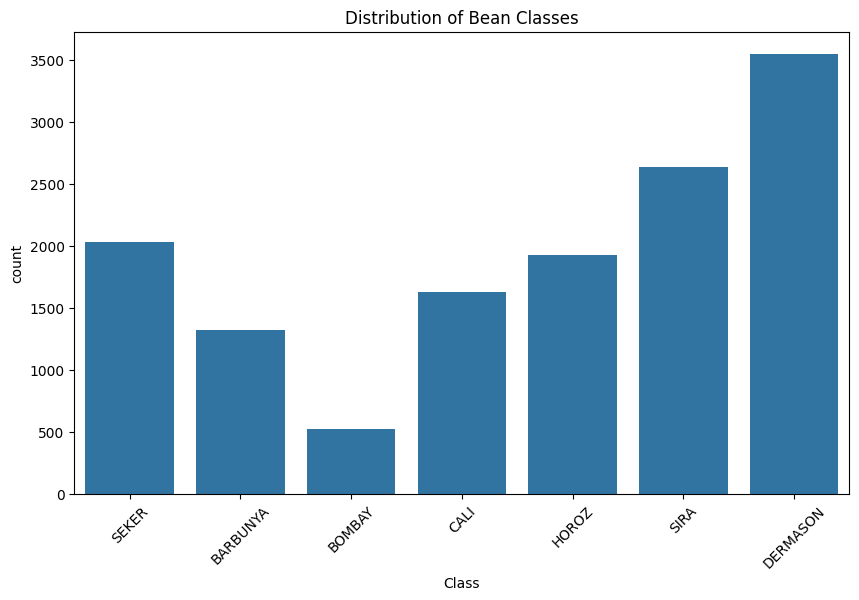

In [51]:
plt.figure(figsize=(10,6))
sns.countplot(x="Class", data=df)
plt.title("Distribution of Bean Classes")
plt.xticks(rotation=45)
plt.show()


Interpretation:

The class distribution analysis revealed a moderate class imbalance in the dataset. DERMASON was the  most frequent bean type with approximately 3540 samples, whereas BOMBAY was the least represented with around 520 samples. The imbalance  may bias machine learning models toward majority classes, potentially reducing classification performance on minority classes. To address this issue, techniques such as SMOTE will be explored during the model development. Additionally, performance will be evaluated using class wise Precision, Recall and F1-score rather than relying solely on overall accuracy. 

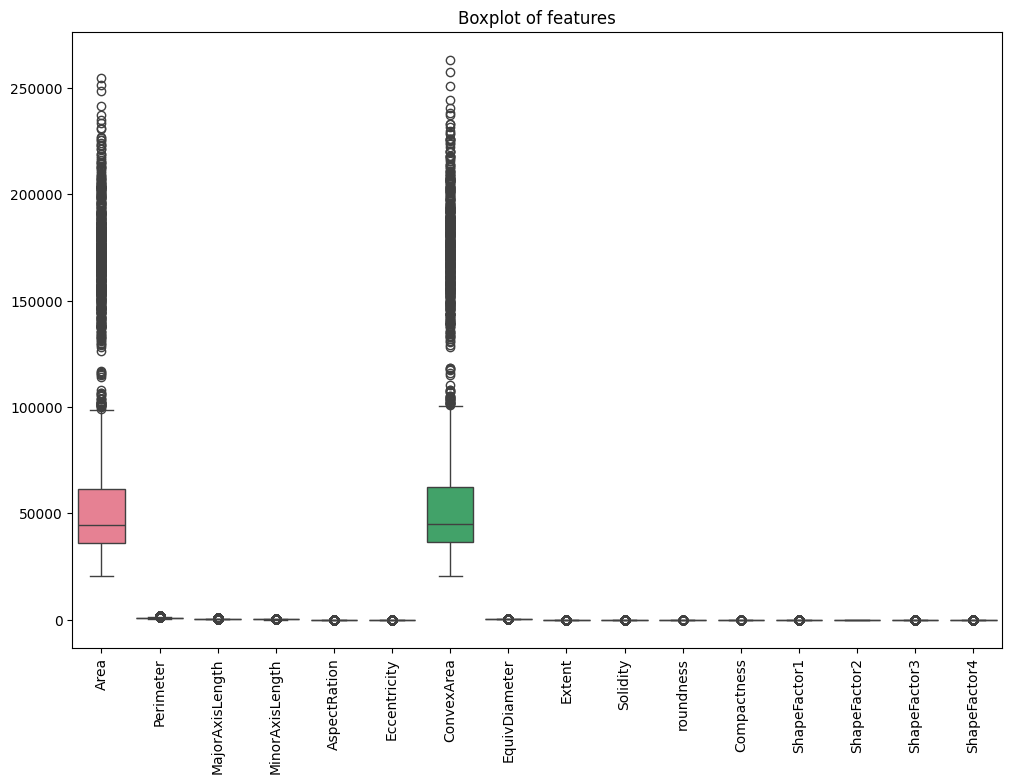

In [52]:
# Boxplot

plt.figure(figsize=(12,8))
sns.boxplot(data=df.drop("Class", axis=1))
plt.xticks(rotation=90)
plt.title("Boxplot of features")
plt.show()


Interpretation:

The boxplot analysis reveals substantial variation in feature distributions across the dataset. Area and ConvexArea exhibit the widest spread and contain numerous high-value observations, indicating significant differences in bean sizes. Several features display apparent outliers; however, these observations are likely due to natural variation among bean classes rather than data quality issues. Additionally, the features are measured on different scales, highlighting the need for feature standardization before model training.


I analyzed outliers using boxplots and observed that many extreme values are due to natural variation among different bean types. Since removing them could remove important class specific information, I retained them and instead used StandardScaler to handle scale differences.




In [53]:
# Encode Target Variable

le = LabelEncoder()
df["Class"] = le.fit_transform(df["Class"])


In [54]:
# Checking Skewness of the features

skewness = df.drop("Class", axis=1).skew()
skewness

Area               2.952931
Perimeter          1.626124
MajorAxisLength    1.357815
MinorAxisLength    2.238211
AspectRation       0.582573
Eccentricity      -1.062824
ConvexArea         2.941821
EquivDiameter      1.948958
Extent            -0.895348
Solidity          -2.550093
roundness         -0.635749
Compactness        0.037115
ShapeFactor1      -0.534141
ShapeFactor2       0.301226
ShapeFactor3       0.242481
ShapeFactor4      -2.759483
dtype: float64

Here highly skewed features are Area, Perimeter, MajorAxisLength, MinorAxisLength, ConvexArea, EquivDiameter.

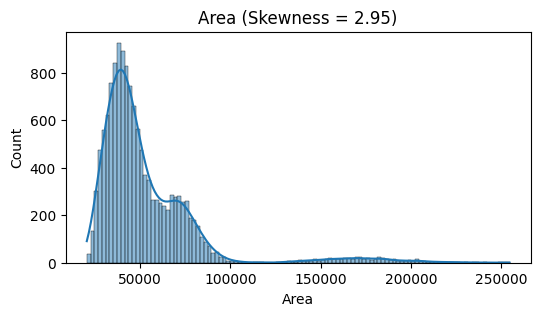

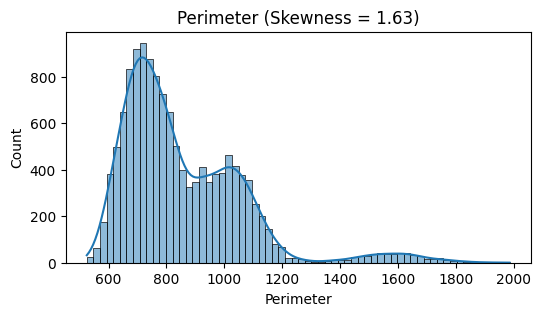

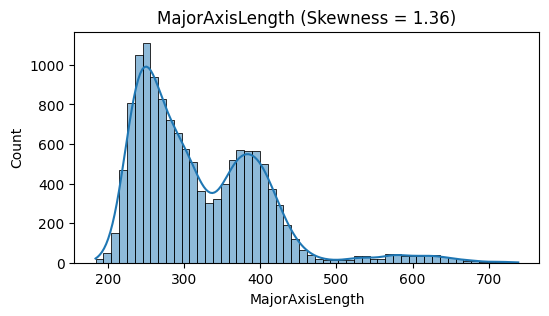

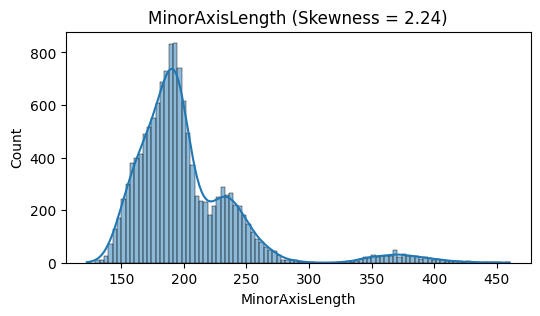

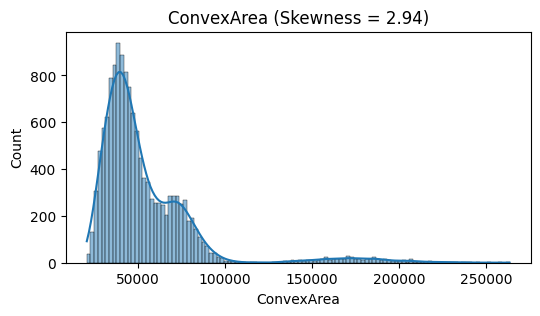

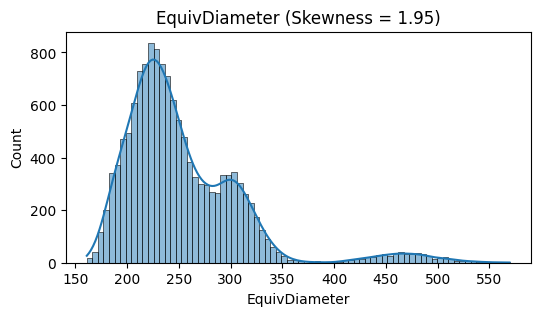

In [55]:
# visualize skewness

columns = df[["Area", "Perimeter", "MajorAxisLength", "MinorAxisLength", "ConvexArea", "EquivDiameter"]]

for col in columns:
    plt.figure(figsize=(6,3))
    sns.histplot(df[col], kde=True)
    plt.title(f"{col} (Skewness = {df[col].skew():.2f})")
    plt.show()

Skewness analysis identified several highly skewed faetures, including Area, ConvexArea and MinorAxisLength. Since the project focuses on classification and includes tree based algorithms that are robust to skewed distributions, no skewness transformation was applied initially. Feature standardization was performed and model performance will be evaluated on the original feature set.

In [56]:
# feature and target split

x = df.drop("Class", axis=1)
y = df["Class"]


In [57]:
# Train Test Split

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42, stratify=y)

In [58]:
# Saving model columns

model_columns = x.columns
joblib.dump(x.columns.tolist(), "model_columns.pkl")

['model_columns.pkl']

In [59]:
# Feature Scaling

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)


In [60]:
# Handle Class Imbalance using SMOTE

smote = SMOTE(random_state=42)
x_train_smote, y_train_smote = smote.fit_resample(x_train_scaled, y_train)

In [61]:
# Verify 

pd.Series(y_train_smote).value_counts()

Class
5    2837
4    2837
2    2837
6    2837
3    2837
0    2837
1    2837
Name: count, dtype: int64

SMOTE usually increases the smaller classes until they match the size of the largest class present in the training set. Since I applied SMOTE after train test split, the largest class in training data was likely around 2837 samples. So SMOTE generated new synthetic samples for the other classes untile they reached around 2837.
The training dataset is now balanced.

In [62]:
#  Comparing Classification models

models = {
    "Logistic Regression" : LogisticRegression(),
    "Decision Tree" : DecisionTreeClassifier(),
    "Random Forest" : RandomForestClassifier(),
    "Support Vector Machine" : SVC(),
    "K-Nearest Neighbors" : KNeighborsClassifier(),
    "Naive Bayes" : GaussianNB(),
    "XGBoost" : XGBClassifier(),
}

In [63]:
# Training Loop

from sklearn.metrics import precision_score


result = []

for name, model in models.items():
    
    # Train the model
    model.fit(x_train_scaled, y_train)

    # Prediction
    y_train_pred = model.predict(x_train_smote)
    y_test_pred = model.predict(x_test_scaled)

    # Accuracy
    train_acc = accuracy_score(y_train_smote, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    # Precision, Recall, F1-Score

    precision = precision_score(y_test, y_test_pred, average = "weighted")
    recall = recall_score(y_test, y_test_pred, average = "weighted")
    f1 = f1_score(y_test, y_test_pred, average = "weighted")

    #Checking Overfitting

    gap = train_acc - test_acc

    if gap > 0.1:
        overfitting = "Yes"
    else:
        overfitting = "No"

    # Storing results
    result.append({
        "Model" : name,
        "Train Accuracy" : train_acc,
        "Test Accuracy" : test_acc,
        "Precision" : precision,
        "Recall" : recall,
        "F1-Score" : f1,
        "Overfitting" : overfitting
                })
    
result_df = pd.DataFrame(result, columns = ["Model", "Train Accuracy", "Test Accuracy", "Precision", "Recall", "F1-Score", "Overfitting"])
result_df

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1-Score,Overfitting
0,Logistic Regression,0.940229,0.921410,0.922178,0.921410,0.921590,No
1,Decision Tree,0.985347,0.892765,0.892603,0.892765,0.892600,No
2,Random Forest,0.989677,0.918472,0.918385,0.918472,0.918307,No
3,Support Vector Machine,0.947278,0.922145,0.922426,0.922145,0.922177,No
4,K-Nearest Neighbors,0.955587,0.916636,0.917409,0.916636,0.916805,No
5,Naive Bayes,0.910821,0.897907,0.900702,0.897907,0.898075,No
6,XGBoost,0.993001,0.926552,0.926833,0.926552,0.926582,No


Interpretation:

After evaluating multiple classification algorithms, including Logistic Regression, Decision Tree, Random Forest, Support Vector Machine (SVM), K-Nearest Neighbors, Naive Bayes, and XGBoost, the top-performing models were selected for further optimization. The selection was based on Test Accuracy and F1-Score, as these metrics provide a reliable measure of classification performance on unseen data.

XGBoost achieved the highest Test Accuracy (92.66%) and F1-Score (92.66%), followed by Random Forest (92.25% Accuracy, 92.24% F1-Score) and SVM (92.21% Accuracy, 92.22% F1-Score). Since these three models demonstrated the best predictive performance, they were chosen for hyperparameter tuning using RandomizedSearchCV to further improve their generalization capability and classification accuracy.

In [64]:
# XGBoost Hyperparameter Tuning

xgb_model = XGBClassifier(random_state=42, eval_metric="mlogloss")

xgb_params = {
    'n_estimators':[100,200,300],
    'max_depth':[3,5,7],
    'learning_rate':[0.01,0.05,0.1],
    'subsample':[0.8,0.9,1.0],
    'colsample_bytree':[0.8,0.9,1.0]
}

xgb_search = RandomizedSearchCV(
    estimator = xgb_model,
    param_distributions = xgb_params,
    n_iter = 20,
    scoring = "accuracy",
    random_state = 42,
    n_jobs = -1,
    verbose = 2
    
)

xgb_search.fit(x_train_smote, y_train_smote)
print("Best XGBoost Parameters:" , xgb_search.best_params_)
print("Best XGBoost Accuracy:" , xgb_search.best_score_)


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best XGBoost Parameters: {'subsample': 1.0, 'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.1, 'colsample_bytree': 0.9}
Best XGBoost Accuracy: 0.9609755952204339


In [65]:
# Random Forest Hyperparameter Tuning

rf_model = RandomForestClassifier(random_state=42)

rf_params = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_search = RandomizedSearchCV(
    estimator = rf_model,
    param_distributions = rf_params,
    n_iter = 20,
    scoring = "accuracy",
    random_state = 42,
    n_jobs = -1,
    verbose = 2
)

rf_search.fit(x_train_smote, y_train_smote)
print("Best Random Forest Parameters:" , rf_search.best_params_)
print("Best Random Forest Accuracy:" ,rf_search.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Random Forest Parameters: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 30}
Best Random Forest Accuracy: 0.9555371103136207


In [66]:
# SVM Hyperparameter Tuning

svm_model = SVC(random_state=42)

svm_params = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

svm_search = RandomizedSearchCV(
    estimator = svm_model,
    param_distributions = svm_params,
    n_iter = 20,
    scoring ="accuracy",
    random_state = 42,
    n_jobs = -1,
    verbose = 2
)

svm_search.fit(x_train_smote, y_train_smote)
print("Best SVM Parameters:" , svm_search.best_params_)
print("Best SVM Accuracy:" , svm_search.best_score_)




Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best SVM Parameters: {'kernel': 'rbf', 'gamma': 'scale', 'C': 100}
Best SVM Accuracy: 0.9537241171707367


In [67]:
# Comparing the Tuned models

tuned_models = {
    'Tuned XGBoost' : xgb_search.best_estimator_,
    'Tuned Random Forest' : rf_search.best_estimator_,
    'Tuned SVM' : svm_search.best_estimator_
    }

result_tuned = []

for name, model in tuned_models.items():

    y_pred = model.predict(x_test_scaled)

    result_tuned.append({
        "Model" : name,
        "Accuracy" : accuracy_score(y_test, y_pred),
        "Precision" : precision_score(y_test, y_pred, average = "weighted"),
        "Recall" : recall_score(y_test, y_pred, average = "weighted"),
        "F1-Score" : f1_score(y_test, y_pred, average = "weighted")

    })
    
    
tuned_results = pd.DataFrame(result_tuned)
tuned_results




,Model,Accuracy,Precision,Recall,F1-Score
0,Tuned XGBoost,0.923614,0.923666,0.923614,0.923599
1,Tuned Random Forest,0.921043,0.921097,0.921043,0.921023
2,Tuned SVM,0.926184,0.926261,0.926184,0.926171


Interpretation:

Initially XGBoost was the best performing model, so it was selected for further investigation along with Random Forest and SVM.

Hyperparameter tuning was performed on the top three models (XGBoost, Random Forest, and SVM) using RandomizedSearchCV with 5-fold cross-validation. After tuning, the models were evaluated on the test dataset using Accuracy, Precision, Recall, and F1-Score.

The Tuned SVM model achieved the highest Accuracy (92.62%), Precision (92.63%), Recall (92.62%), and F1-Score (92.62%), outperforming the tuned XGBoost and Random Forest models. Therefore, Tuned SVM was selected as the final model for dry bean type classification due to its superior predictive performance and generalization capability on unseen data.

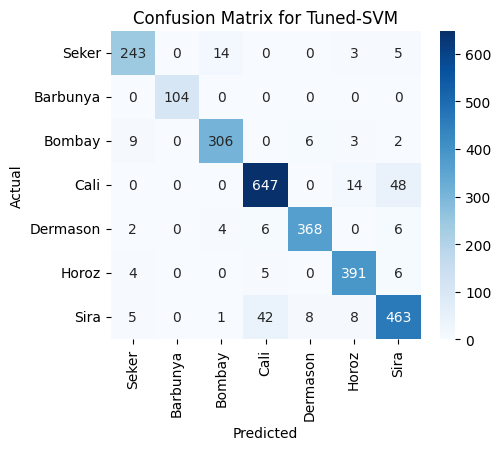

In [68]:
# Confusion Matrix for SVM

svm_model = SVC(
    C= 100,
    kernel = "rbf",
    gamma = "scale"
 )

svm_model.fit(x_train_smote, y_train_smote)

y_pred_svm = svm_model.predict(x_test_scaled)

classes = ["Seker", "Barbunya", "Bombay", "Cali", "Dermason", "Horoz", "Sira"]
cm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels = classes,
    yticklabels = classes
)

plt.title("Confusion Matrix for Tuned-SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Interpretation:

The confusion matrix indicates that the Tuned SVM model performs well across all seven bean classes, with most predictions concentrated along the diagonal, representing correct classifications. Barbunya beans were classified perfectly with no misclassifications. Cali, Horoz, Dermason, Bombay, and Seker also achieved high classification accuracy.

The most significant classification errors occurred between Cali and Sira, where 48 Cali beans were classified as Sira and 42 Sira beans were classified as Cali. This suggests that these two bean varieties share similar physical characteristics, making them more difficult to distinguish. Despite these challenges, the model achieved an overall accuracy of approximately 92.6%, demonstrating strong predictive performance for dry bean type classification.

In [69]:
# Saving the svm model

joblib.dump(svm_model, "svm_model.pkl")

['svm_model.pkl']

In [70]:
# saving the scaler

joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [71]:
# Saving the encoder

joblib.dump(le, "label_encoder.pkl")

['label_encoder.pkl']